# P-ML11 — HMM Regime Classifier for Late-Bull Detection

**Goal:** Use a Gaussian HMM to discover latent market states that distinguish
"early/mid bull" from "late/overextended bull", fixing the Fold 2 ATH+crash
failure (bull IC = -0.128 in P-ML7).

**Hypothesis H4:** An HMM trained on momentum/volatility features can detect
late-bull overextension, improving bull-regime predictions — especially Fold 2.

**Two experiments:**
- **Exp-A (HMM features):** Add one-hot HMM state columns to the LightGBM
  feature matrix. The bull model can learn to be conservative when the HMM
  indicates late-bull.
- **Exp-B (HMM gating):** When HMM predicts "late-bull", dampen the signal
  by a configurable factor (0.0, 0.3, 0.5).

**HMM observations (4 features):**
1. `ret_20` — 20-bar cumulative return (trend strength)
2. `atr_pct` — ATR/close (volatility level)
3. `mom_zscore_20` — z-score of 20-bar return (overextension)
4. `ret_5_minus_20` — short minus medium momentum (acceleration/exhaustion)

**Baselines:**
- P-ML7/P-ML9 binary: Sharpe +1.234, Fold 2 bull IC = -0.128
- P-ML9 scaled: Sharpe +1.583, MaxDD -33.6%

## §1 — Config

In [1]:
import sys
from pathlib import Path

repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         9,
})

# -- Dataset / walk-forward config ---------------------------------------------
SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

# -- HMM parameters -----------------------------------------------------------
N_HMM_STATES = 4
HMM_RANDOM_STATE = 42

# -- Reference metrics ---------------------------------------------------------
P_ML7_ICS  = [0.0721, 0.0091, 0.1283, 0.0537, 0.1069]
P_ML7_BULL_ICS = [np.nan, -0.128, 0.179, 0.058, 0.071]  # Fold 2 is the problem
P_ML7      = {"return": 19.976, "sharpe": 1.261, "maxdd": -0.773}
P_ML9_SC   = {"return": 7.587, "sharpe": 1.583, "maxdd": -0.336}
BUY_HOLD   = {"return": 8.766, "sharpe": 1.052, "maxdd": -0.766}

print(f"Dataset:    {SINCE} -> {UNTIL} | 1d | horizon={HORIZON}")
print(f"Walk-fwd:   {N_SPLITS} folds, train_frac={TRAIN_FRAC}")
print(f"HMM:        {N_HMM_STATES} states, seed={HMM_RANDOM_STATE}")
print(f"Features:   FEATURES_V2 ({len(FEATURES_V2)}) + HMM state columns")

Dataset:    2019-01-01 -> 2025-01-01 | 1d | horizon=1
Walk-fwd:   5 folds, train_frac=0.6
HMM:        4 states, seed=42
Features:   FEATURES_V2 (16) + HMM state columns


## §2 — Data Loading

In [2]:
from data.fetch import fetch_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier, HMMRegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from strategies.ml import RegimeLGBMStrategy
from backtesting import compute_metrics

# -- Load data -----------------------------------------------------------------
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)
if df_raw.index.min() > pd.Timestamp("2020-01-01", tz="UTC"):
    df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d",
                         since=SINCE, until=UNTIL, use_cache=False)
print(f"Loaded {len(df_raw):,} bars  |  {df_raw.index[0].date()} -> {df_raw.index[-1].date()}")

# -- Build features + labels + regimes -----------------------------------------
feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

comb = pd.concat([feats_base, feats_mom, label, reg["regime"]], axis=1).dropna()

X_v2       = comb[FEATURES_V2]
y_all      = comb[label.name]
regime_all = comb["regime"].fillna("ranging")

bar_ret_daily = np.log(df_raw["close"] / df_raw["close"].shift(1)).reindex(comb.index)
splits = list(purged_wf_splits(len(comb), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"{len(comb):,} usable bars | {comb.index[0].date()} -> {comb.index[-1].date()}")
print(f"Splits: {N_SPLITS} folds")

Loaded 2,193 bars  |  2019-01-01 -> 2025-01-01
2,132 usable bars | 2019-03-02 -> 2024-12-31
Splits: 5 folds


## §3 — HMM Exploration (full-dataset fit for visualization only)

Fit the HMM on the entire dataset to visualize what states it discovers.
**Not used for backtesting** — walk-forward fits are in §4 and §5.

In [3]:
# -- Fit HMM on full dataset (exploratory only) --------------------------------
hmm_full = HMMRegimeClassifier(n_states=N_HMM_STATES, random_state=HMM_RANDOM_STATE)
hmm_full.fit(df_raw)
print(f"HMM fitted: {hmm_full}")
print(f"Converged: {hmm_full._model.monitor_.converged}")

# -- State summary: mean observation values per state --------------------------
summary = hmm_full.state_summary(df_raw)
print("\nState summary (mean observation values):")
print(summary.round(4).to_string())

# -- Interpret states ----------------------------------------------------------
states_full = hmm_full.predict(df_raw).reindex(comb.index)
regime_full = regime_all.copy()

# Map states to interpretable labels based on ret_20 and mom_zscore_20
state_labels = {}
for s in range(N_HMM_STATES):
    row = summary.loc[s]
    if row["ret_20"] > 0.05 and row["mom_zscore_20"] > 0.5:
        state_labels[s] = "late_bull"
    elif row["ret_20"] > 0.02:
        state_labels[s] = "early_bull"
    elif row["ret_20"] < -0.05:
        state_labels[s] = "bear"
    else:
        state_labels[s] = "ranging"
print(f"\nState label mapping: {state_labels}")

# Count bars per state
for s in range(N_HMM_STATES):
    n = int((states_full == s).sum())
    bull_n = int(((states_full == s) & (regime_full == "bull")).sum())
    print(f"  State {s} ({state_labels.get(s, '?'):>12}): {n:>5} bars, {bull_n:>4} bull")

HMM fitted: HMMRegimeClassifier(n_states=4, cov=full, status=fitted)
Converged: True

State summary (mean observation values):
       ret_20  atr_pct  mom_zscore_20  ret_5_minus_20
state                                                
0     -0.0679   0.0508        -0.7670          0.0579
1     -0.0209   0.0907        -0.3268          0.0134
2      0.0259   0.0318        -0.0708         -0.0203
3      0.1745   0.0476         1.3703         -0.1363

State label mapping: {0: 'bear', 1: 'ranging', 2: 'early_bull', 3: 'late_bull'}
  State 0 (        bear):   587 bars,   83 bull
  State 1 (     ranging):   280 bars,   69 bull
  State 2 (  early_bull):   733 bars,  239 bull
  State 3 (   late_bull):   532 bars,  295 bull


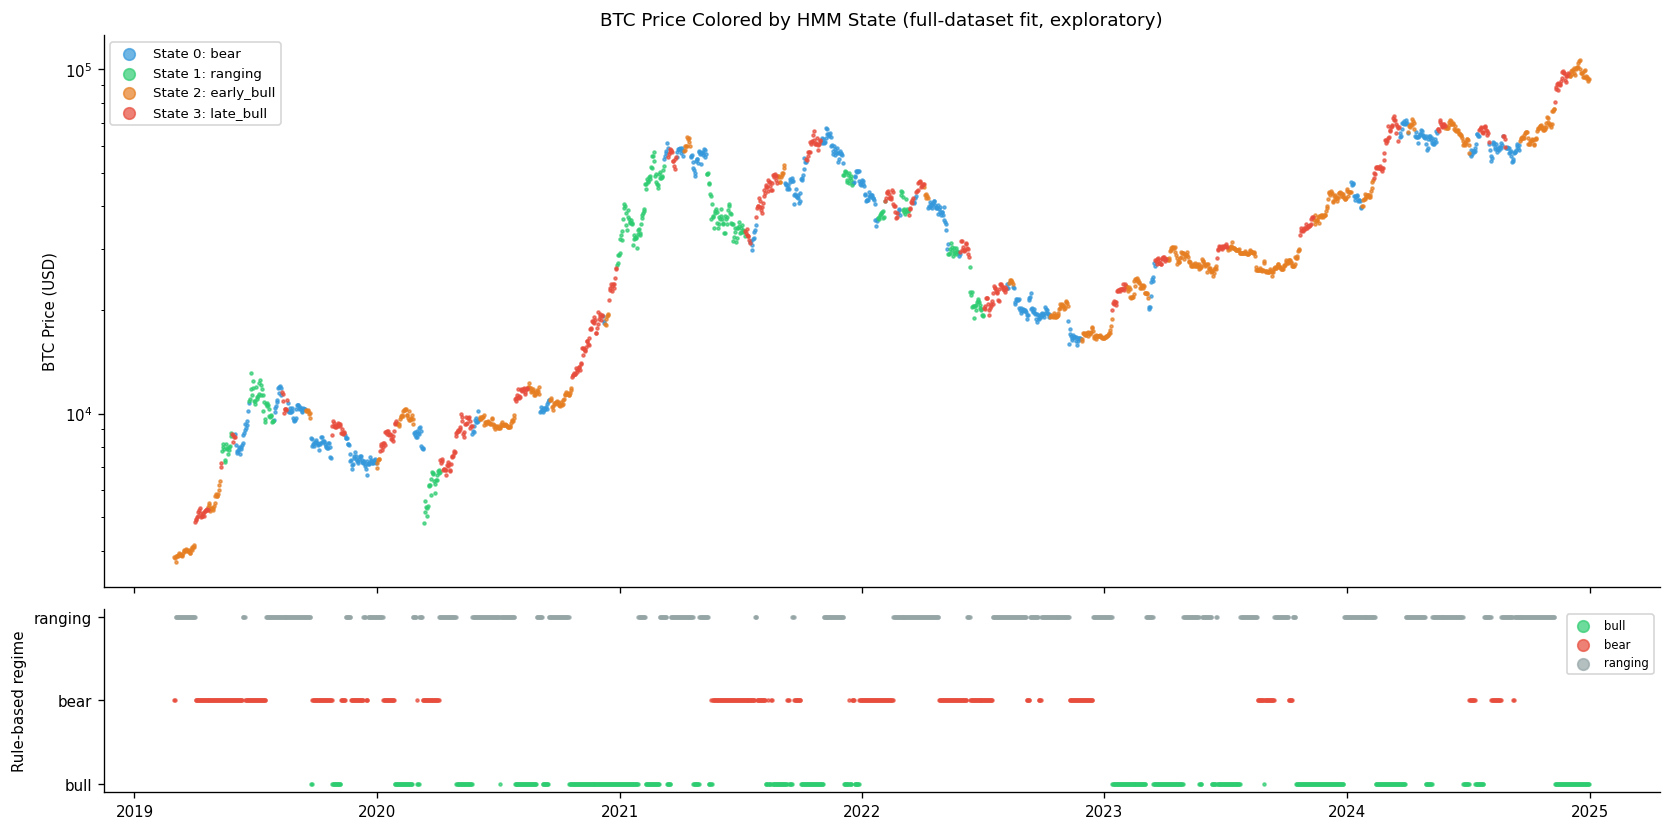

In [4]:
# -- Visualize: BTC price colored by HMM state ---------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]
price = df_raw["close"].reindex(comb.index)

ax = axes[0]
for s in range(N_HMM_STATES):
    mask = (states_full == s)
    ax.scatter(price.index[mask], price[mask],
               c=colors[s % len(colors)], s=3, alpha=0.7,
               label=f"State {s}: {state_labels.get(s, '?')}")
ax.set_ylabel("BTC Price (USD)")
ax.set_title("BTC Price Colored by HMM State (full-dataset fit, exploratory)", fontsize=11)
ax.legend(fontsize=8, markerscale=4)
ax.set_yscale("log")

# Rule-based regime for comparison
ax2 = axes[1]
regime_colors = {"bull": "#2ecc71", "bear": "#e74c3c", "ranging": "#95a5a6"}
for regime_name, color in regime_colors.items():
    mask = (regime_full == regime_name)
    ax2.scatter(price.index[mask], [regime_name] * mask.sum(),
                c=color, s=3, alpha=0.7, label=regime_name)
ax2.set_ylabel("Rule-based regime")
ax2.legend(fontsize=7, markerscale=4, loc="upper right")

plt.tight_layout()
plt.show()

## §4 — Walk-Forward Baseline + Exp-A (HMM Features)

For each fold:
1. Train HMM on training OHLCV (causal — no look-ahead)
2. Predict HMM states on test bars → one-hot features
3. Train RegimeEnsemble with FEATURES_V2 + HMM one-hot (20 features)
4. Compare IC (especially Fold 2 bull IC) vs P-ML7 baseline

In [5]:
idx = comb.index

# HMM feature column names
HMM_FEAT_COLS = [f"hmm_state_{s}" for s in range(N_HMM_STATES)]
FEATURES_V2_HMM = FEATURES_V2 + HMM_FEAT_COLS

fold_baseline = []   # P-ML7 reproduction (no HMM)
fold_exp_a    = []   # Exp-A: HMM one-hot features

header = (f"{'Fold':<5} {'Period':<28} "
          f"{'Base IC':>8} {'ExpA IC':>8} {'dIC':>6} "
          f"{'Bull IC base':>12} {'Bull IC A':>10} {'dBullIC':>8}")
print(header)
print("-" * 100)

for i, (tr, te) in enumerate(splits):
    period = f"{idx[te[0]].date()} -> {idx[te[-1]].date()}"

    # -- Baseline: standard P-ML7 ensemble (no HMM) ---------------------------
    ens_base = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ens_base.fit(X_v2.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
    preds_base = ens_base.predict(X_v2.iloc[te], regime_all.iloc[te])
    actual     = y_all.iloc[te].values
    ic_base, _ = stats.spearmanr(preds_base, actual)

    # Bull-specific IC
    bull_te = (regime_all.iloc[te] == "bull").values
    if bull_te.sum() > 10:
        ic_bull_base, _ = stats.spearmanr(preds_base[bull_te], actual[bull_te])
    else:
        ic_bull_base = np.nan

    fold_baseline.append({
        "fold": i+1, "te": te, "IC": ic_base, "bull_IC": ic_bull_base,
        "preds": preds_base,
    })

    # -- Exp-A: HMM features added to FEATURES_V2 -----------------------------
    # Fit HMM on training OHLCV (use df_raw rows corresponding to training bars)
    train_dates = idx[tr]
    test_dates  = idx[te]

    # Need enough OHLCV context for HMM warmup (ret_20, ATR, etc.)
    # Use df_raw from start up to end of training period
    train_end_loc = df_raw.index.get_loc(train_dates[-1])
    df_train_ohlcv = df_raw.iloc[:train_end_loc + 1]

    hmm_rc = HMMRegimeClassifier(n_states=N_HMM_STATES, random_state=HMM_RANDOM_STATE)
    hmm_rc.fit(df_train_ohlcv)

    # Build HMM features for all bars (train+test) using the training-fitted HMM
    # For test bars, we need enough context too
    test_end_loc = df_raw.index.get_loc(test_dates[-1])
    df_all_ohlcv = df_raw.iloc[:test_end_loc + 1]
    hmm_feats = hmm_rc.build_features(df_all_ohlcv).reindex(idx)

    # Build expanded feature matrix
    X_hmm = pd.concat([X_v2, hmm_feats[HMM_FEAT_COLS]], axis=1)
    # Fill NaN in HMM columns with 0 (warmup bars)
    X_hmm[HMM_FEAT_COLS] = X_hmm[HMM_FEAT_COLS].fillna(0)

    ens_a = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ens_a.fit(X_hmm.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
    preds_a = ens_a.predict(X_hmm.iloc[te], regime_all.iloc[te])
    ic_a, _ = stats.spearmanr(preds_a, actual)

    if bull_te.sum() > 10:
        ic_bull_a, _ = stats.spearmanr(preds_a[bull_te], actual[bull_te])
    else:
        ic_bull_a = np.nan

    fold_exp_a.append({
        "fold": i+1, "te": te, "IC": ic_a, "bull_IC": ic_bull_a,
        "preds": preds_a, "hmm_rc": hmm_rc,
        "hmm_states_test": hmm_rc.predict(df_all_ohlcv).reindex(test_dates),
    })

    d_ic = ic_a - ic_base
    d_bull = ic_bull_a - ic_bull_base if not (np.isnan(ic_bull_a) or np.isnan(ic_bull_base)) else np.nan
    print(f"  {i+1:<3} {period:<28} "
          f"{ic_base:>+8.4f} {ic_a:>+8.4f} {d_ic:>+6.3f} "
          f"{ic_bull_base:>+12.4f} {ic_bull_a:>+10.4f} "
          f"{d_bull:>+8.4f}" if not np.isnan(d_bull) else
          f"  {i+1:<3} {period:<28} "
          f"{ic_base:>+8.4f} {ic_a:>+8.4f} {d_ic:>+6.3f} "
          f"{'nan':>12} {'nan':>10} {'nan':>8}")

# -- Aggregate comparison -----------------------------------------------------
ics_base = [r["IC"] for r in fold_baseline]
ics_a    = [r["IC"] for r in fold_exp_a]
print()
print(f"Mean IC:  Baseline={np.mean(ics_base):+.4f}  Exp-A={np.mean(ics_a):+.4f}  "
      f"delta={np.mean(ics_a)-np.mean(ics_base):+.4f}")
print(f"ICIR:     Baseline={np.mean(ics_base)/np.std(ics_base):.3f}  "
      f"Exp-A={np.mean(ics_a)/np.std(ics_a):.3f}")

Fold  Period                        Base IC  ExpA IC    dIC Bull IC base  Bull IC A  dBullIC
----------------------------------------------------------------------------------------------------


  1   2020-02-20 -> 2021-02-08      +0.0721  +0.0537 -0.018          nan        nan      nan


  2   2021-02-09 -> 2022-01-29      +0.0091  +0.0118 +0.003      -0.1278    -0.1319  -0.0041


  3   2022-01-30 -> 2023-01-19      +0.1283  +0.1178 -0.011          nan        nan      nan


  4   2023-01-20 -> 2024-01-09      +0.0537  +0.0451 -0.009      +0.0582    +0.0613  +0.0031


  5   2024-01-10 -> 2024-12-29      +0.1069  +0.1007 -0.006      +0.0714    +0.0607  -0.0107

Mean IC:  Baseline=+0.0740  Exp-A=+0.0658  delta=-0.0082
ICIR:     Baseline=1.779  Exp-A=1.709


In [6]:
# -- Equity curves: baseline vs Exp-A ------------------------------------------
def build_equity(fold_list, bar_ret_daily, idx):
    pieces, anchor = [], 1.0
    for r in fold_list:
        te   = r["te"]
        pos  = np.sign(r["preds"])
        ret  = bar_ret_daily.iloc[te].values
        pos_sh    = np.roll(pos, 1)
        pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret)
        eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)

oos_base = build_equity(fold_baseline, bar_ret_daily, idx)
oos_a    = build_equity(fold_exp_a,    bar_ret_daily, idx)
bah      = df_raw["close"].reindex(oos_base.index)
bah      = bah / bah.iloc[0]

m_base = compute_metrics(oos_base)
m_a    = compute_metrics(oos_a)
m_bah  = compute_metrics(bah)

print(f"\n{'Strategy':<35} {'Return':>10} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 65)
for name, m in [("Buy & Hold", m_bah), ("Baseline (P-ML7)", m_base), ("Exp-A (HMM features)", m_a)]:
    print(f"  {name:<33} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}  {m['max_drawdown']*100:>7.1f}%")


Strategy                                Return   Sharpe    MaxDD
-----------------------------------------------------------------
  Buy & Hold                           +876.6%   +1.052    -76.6%
  Baseline (P-ML7)                    +1815.4%   +1.234    -77.3%
  Exp-A (HMM features)                +1043.0%   +1.074    -77.2%


## §5 — Exp-B: HMM Gating

When the HMM predicts the highest-numbered state (most bullish = likely late-bull),
dampen the signal by a gate factor. Test gate_factor = {0.0, 0.3, 0.5}.

In [7]:
# -- Exp-B: HMM gating on baseline predictions --------------------------------
LATE_BULL_STATE = N_HMM_STATES - 1  # highest state = most bullish by sort order
GATE_FACTORS = [0.0, 0.3, 0.5]

gate_results = {}

for gf in GATE_FACTORS:
    fold_gated = []
    for i, (tr, te) in enumerate(splits):
        # Reuse baseline predictions
        preds = fold_baseline[i]["preds"].copy()
        signals = np.sign(preds)

        # Get HMM states for test bars (from Exp-A, already fitted causally)
        hmm_states = fold_exp_a[i]["hmm_states_test"].values

        # Gate: when HMM state == late-bull AND signal is long, dampen
        late_bull_mask = (hmm_states == LATE_BULL_STATE)
        signals[late_bull_mask & (signals > 0)] *= gf

        fold_gated.append({
            "fold": i+1, "te": te, "preds": preds,
            "signals_gated": pd.Series(signals, index=idx[te]),
            "n_gated": int((late_bull_mask & (np.sign(preds) > 0)).sum()),
        })

    # Build equity
    pieces, anchor = [], 1.0
    for r in fold_gated:
        te  = r["te"]
        pos = r["signals_gated"].values
        ret = bar_ret_daily.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    oos_g = pd.concat(pieces)
    m_g = compute_metrics(oos_g)

    n_gated_total = sum(r["n_gated"] for r in fold_gated)
    gate_results[gf] = {"metrics": m_g, "equity": oos_g, "folds": fold_gated,
                         "n_gated": n_gated_total}

# -- Print results -------------------------------------------------------------
print(f"Late-bull state: {LATE_BULL_STATE} (highest ret_20 by HMM sort order)")
print()
print(f"{'Gate factor':<15} {'Return':>10} {'Sharpe':>8} {'MaxDD':>8} {'Bars gated':>12}")
print("-" * 58)
print(f"  {'Baseline':<13} {m_base['total_return']*100:>+9.1f}%  {m_base['sharpe_ratio']:>+7.3f}  "
      f"{m_base['max_drawdown']*100:>7.1f}%  {'0':>12}")
for gf in GATE_FACTORS:
    m = gate_results[gf]["metrics"]
    n = gate_results[gf]["n_gated"]
    print(f"  {gf:<13} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}  "
          f"{m['max_drawdown']*100:>7.1f}%  {n:>12}")

Late-bull state: 3 (highest ret_20 by HMM sort order)

Gate factor         Return   Sharpe    MaxDD   Bars gated
----------------------------------------------------------
  Baseline        +1815.4%   +1.234    -77.3%             0
  0.0              +364.9%   +0.812    -79.9%           230
  0.3              +636.6%   +0.964    -77.2%           230
  0.5              +884.1%   +1.055    -76.8%           230


## §6 — Sensitivity: n_states and random seeds

In [8]:
# -- Sensitivity: n_states -----------------------------------------------------
n_states_list = [3, 4, 5]
sens_results = []

for ns in n_states_list:
    fold_sens = []
    for i, (tr, te) in enumerate(splits):
        train_dates = idx[tr]
        test_dates  = idx[te]
        train_end_loc = df_raw.index.get_loc(train_dates[-1])
        test_end_loc  = df_raw.index.get_loc(test_dates[-1])

        hmm_s = HMMRegimeClassifier(n_states=ns, random_state=HMM_RANDOM_STATE)
        hmm_s.fit(df_raw.iloc[:train_end_loc + 1])

        hmm_f = hmm_s.build_features(df_raw.iloc[:test_end_loc + 1]).reindex(idx)
        hmm_cols = [f"hmm_state_{s}" for s in range(ns)]
        X_s = pd.concat([X_v2, hmm_f[hmm_cols].fillna(0)], axis=1)

        ens_s = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens_s.fit(X_s.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
        preds_s = ens_s.predict(X_s.iloc[te], regime_all.iloc[te])
        actual  = y_all.iloc[te].values
        ic_s, _ = stats.spearmanr(preds_s, actual)
        fold_sens.append({"fold": i+1, "IC": ic_s, "preds": preds_s, "te": te})

    oos_s = build_equity(fold_sens, bar_ret_daily, idx)
    m_s   = compute_metrics(oos_s)
    ics_s = [r["IC"] for r in fold_sens]
    sens_results.append({
        "n_states": ns, "mean_ic": np.mean(ics_s),
        "sharpe": m_s["sharpe_ratio"], "maxdd": m_s["max_drawdown"],
        "return": m_s["total_return"],
    })

print(f"{'n_states':<10} {'Mean IC':>8} {'Sharpe':>8} {'MaxDD':>8} {'Return':>10}")
print("-" * 48)
print(f"  {'base':<8} {np.mean(ics_base):>+8.4f} {m_base['sharpe_ratio']:>+7.3f}  "
      f"{m_base['max_drawdown']*100:>7.1f}% {m_base['total_return']*100:>+9.1f}%")
for sr in sens_results:
    print(f"  {sr['n_states']:<8} {sr['mean_ic']:>+8.4f} {sr['sharpe']:>+7.3f}  "
          f"{sr['maxdd']*100:>7.1f}% {sr['return']*100:>+9.1f}%")

# -- Sensitivity: random seeds (with n_states=4) ------------------------------
seeds = [42, 123, 456, 789, 2026]
seed_ics = []

for seed in seeds:
    fold_ics = []
    for i, (tr, te) in enumerate(splits):
        train_dates = idx[tr]
        test_dates  = idx[te]
        train_end_loc = df_raw.index.get_loc(train_dates[-1])
        test_end_loc  = df_raw.index.get_loc(test_dates[-1])

        hmm_seed = HMMRegimeClassifier(n_states=N_HMM_STATES, random_state=seed)
        hmm_seed.fit(df_raw.iloc[:train_end_loc + 1])

        hmm_f = hmm_seed.build_features(df_raw.iloc[:test_end_loc + 1]).reindex(idx)
        X_seed = pd.concat([X_v2, hmm_f[HMM_FEAT_COLS].fillna(0)], axis=1)

        ens_seed = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens_seed.fit(X_seed.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
        preds_seed = ens_seed.predict(X_seed.iloc[te], regime_all.iloc[te])
        ic_seed, _ = stats.spearmanr(preds_seed, y_all.iloc[te].values)
        fold_ics.append(ic_seed)
    seed_ics.append(fold_ics)

print(f"\nSeed stability (n_states={N_HMM_STATES}):")
print(f"{'Seed':<8} " + "  ".join(f"F{i+1:>2}" for i in range(N_SPLITS)) + f"  {'Mean IC':>8}")
print("-" * 60)
for seed, ics in zip(seeds, seed_ics):
    ic_str = "  ".join(f"{ic:>+.3f}" for ic in ics)
    print(f"  {seed:<6} {ic_str}  {np.mean(ics):>+8.4f}")
print(f"\nIC std across seeds: {np.std([np.mean(s) for s in seed_ics]):.4f}")

n_states    Mean IC   Sharpe    MaxDD     Return
------------------------------------------------
  base      +0.0740  +1.234    -77.3%   +1815.4%
  3         +0.0673  +1.242    -77.4%   +1871.8%
  4         +0.0658  +1.074    -77.2%   +1043.0%
  5         +0.0565  +0.918    -75.0%    +590.2%



Seed stability (n_states=4):
Seed     F 1  F 2  F 3  F 4  F 5   Mean IC
------------------------------------------------------------
  42     +0.054  +0.012  +0.118  +0.045  +0.101   +0.0658
  123    +0.050  -0.000  +0.117  +0.040  +0.087   +0.0587
  456    +0.034  +0.010  +0.132  +0.048  +0.092   +0.0633
  789    +0.054  +0.020  +0.125  +0.052  +0.090   +0.0683
  2026   +0.054  +0.012  +0.120  +0.044  +0.083   +0.0624

IC std across seeds: 0.0032


## §7 — Equity Comparison Plot

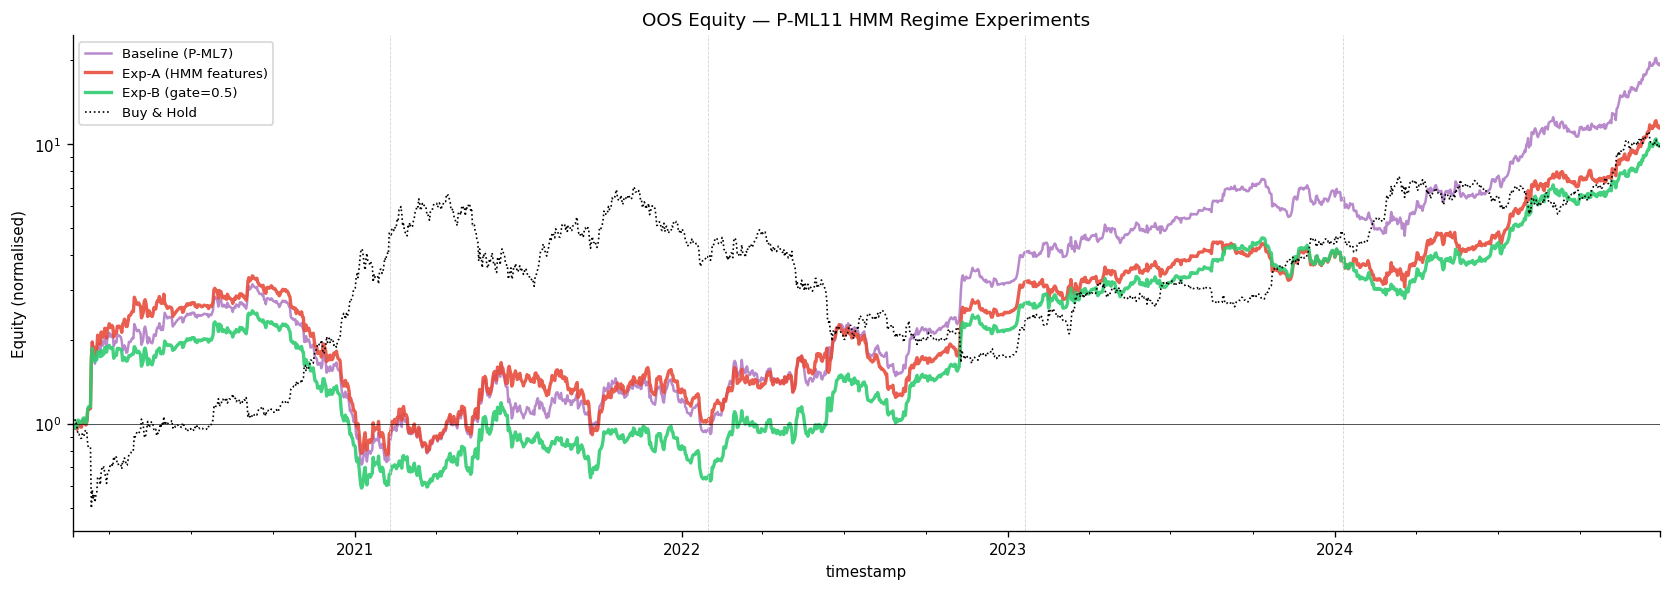

In [9]:
# -- Equity comparison plot -----------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

oos_base.plot(ax=ax, label="Baseline (P-ML7)", color="#9b59b6", linewidth=1.5, alpha=0.7)
oos_a.plot(ax=ax, label="Exp-A (HMM features)", color="#e74c3c", linewidth=2.0, alpha=0.9)

# Best gating result
best_gf = min(GATE_FACTORS, key=lambda g: -gate_results[g]["metrics"]["sharpe_ratio"])
gate_results[best_gf]["equity"].plot(
    ax=ax, label=f"Exp-B (gate={best_gf})", color="#2ecc71", linewidth=2.0, alpha=0.9)

bah.plot(ax=ax, label="Buy & Hold", color="black", linewidth=1.0, linestyle=":")

for _, (tr, te) in enumerate(splits):
    ax.axvline(idx[te[0]], color="lightgray", linewidth=0.5, linestyle="--")
ax.axhline(1, color="black", linewidth=0.4)
ax.set_title("OOS Equity — P-ML11 HMM Regime Experiments", fontsize=11)
ax.set_ylabel("Equity (normalised)")
ax.legend(fontsize=8, loc="upper left")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## §8 — Finding F18 Summary

In [10]:
print("=" * 78)
print("FINDING F18 -- HMM Regime Classifier (P-ML11)")
print("=" * 78)
print()
print(f"HMMRegimeClassifier created in ml/regime/hmm.py")
print(f"  n_states={N_HMM_STATES}, observations: ret_20, atr_pct, mom_zscore_20, ret_5_minus_20")
print()

# -- Summary table -------------------------------------------------------------
print(f"{'Strategy':<35} {'Return':>10} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 65)
all_rows = [
    ("Buy & Hold", m_bah),
    ("Baseline (P-ML7 binary)", m_base),
    ("Exp-A (HMM one-hot features)", m_a),
]
for gf in GATE_FACTORS:
    all_rows.append((f"Exp-B (gate={gf})", gate_results[gf]["metrics"]))
for name, m in all_rows:
    print(f"  {name:<33} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}  {m['max_drawdown']*100:>7.1f}%")

# -- Bull IC comparison --------------------------------------------------------
print(f"\nFold 2 Bull IC (the target fold):")
ic_bull_base_f2 = fold_baseline[1]["bull_IC"]
ic_bull_a_f2    = fold_exp_a[1]["bull_IC"]
print(f"  Baseline:  {ic_bull_base_f2:+.4f}")
print(f"  Exp-A:     {ic_bull_a_f2:+.4f}")
print(f"  Delta:     {ic_bull_a_f2 - ic_bull_base_f2:+.4f}")

# -- Hypothesis verdict --------------------------------------------------------
print()
exp_a_better = m_a["sharpe_ratio"] > m_base["sharpe_ratio"]
best_gate = max(GATE_FACTORS, key=lambda g: gate_results[g]["metrics"]["sharpe_ratio"])
exp_b_better = gate_results[best_gate]["metrics"]["sharpe_ratio"] > m_base["sharpe_ratio"]
fold2_improved = ic_bull_a_f2 > ic_bull_base_f2

print("Hypothesis H4 evaluation:")
print(f"  Exp-A improves overall Sharpe?    {'YES' if exp_a_better else 'NO'} "
      f"({m_a['sharpe_ratio']:+.3f} vs {m_base['sharpe_ratio']:+.3f})")
print(f"  Exp-B improves overall Sharpe?    {'YES' if exp_b_better else 'NO'} "
      f"(best gate={best_gate}: {gate_results[best_gate]['metrics']['sharpe_ratio']:+.3f})")
print(f"  Fold 2 bull IC improved?          {'YES' if fold2_improved else 'NO'} "
      f"({ic_bull_a_f2:+.4f} vs {ic_bull_base_f2:+.4f})")
print()
print("Next steps:")
print("  - If H4 confirmed: integrate HMM features into production pipeline")
print("  - If H4 rejected: late-bull detection may need valuation signals (BTC/stock ratio)")
print("  - H5: Optuna tuning on the 16-feature model (low priority)")

FINDING F18 -- HMM Regime Classifier (P-ML11)

HMMRegimeClassifier created in ml/regime/hmm.py
  n_states=4, observations: ret_20, atr_pct, mom_zscore_20, ret_5_minus_20

Strategy                                Return   Sharpe    MaxDD
-----------------------------------------------------------------
  Buy & Hold                           +876.6%   +1.052    -76.6%
  Baseline (P-ML7 binary)             +1815.4%   +1.234    -77.3%
  Exp-A (HMM one-hot features)        +1043.0%   +1.074    -77.2%
  Exp-B (gate=0.0)                     +364.9%   +0.812    -79.9%
  Exp-B (gate=0.3)                     +636.6%   +0.964    -77.2%
  Exp-B (gate=0.5)                     +884.1%   +1.055    -76.8%

Fold 2 Bull IC (the target fold):
  Baseline:  -0.1278
  Exp-A:     -0.1319
  Delta:     -0.0041

Hypothesis H4 evaluation:
  Exp-A improves overall Sharpe?    NO (+1.074 vs +1.234)
  Exp-B improves overall Sharpe?    NO (best gate=0.5: +1.055)
  Fold 2 bull IC improved?          NO (-0.1319 vs -0.12